# Exercice 2 — Détection de Fraude Bancaire au 02/08/2026

** Construire un système de détection de fraude performant sur un dataset fortement déséquilibré (0.5% de fraude), en comparant 4 stratégies (baseline, class_weight, SMOTE, threshold tuning) et en rendant le modèle interprétable via SHAP.
** `RANDOM_STATE = 42` est fixé partout pour garantir des résultats identiques à chaque exécution.

Istallation

In [18]:
!pip install -q scikit-learn pandas matplotlib seaborn imbalanced-learn shap

Importation

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("visualizations", exist_ok=True)

print("Dossier visualizations créé")

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, precision_recall_curve)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

Dossier visualizations créé


Phase 1 : Exploration du Déséquilibre

### eDataset créer synthétiquement
Le dataset simule 100 000 transactions bancaires avec un déséquilibre de classes réaliste (~0.5% de fraude),
conforme au vrai dataset Kaggle "Credit Card Fraud Detection" : colonnes `Amount`, `Time`, `V1`-`V28`
(features anonymisées par PCA) et `Class` (0 = légitime, 1 = fraude).

In [20]:
n_legit = 99500
n_fraud = 500          # 0.5% de fraude
n_pca = 28              # V1...V28

# --- Transactions légitimes : distribution "normale", peu de dispersion ---
X_legit = np.random.normal(0, 1, size=(n_legit, n_pca))
amount_legit = np.round(np.random.exponential(60, n_legit).clip(1, 5000), 2)

# --- Transactions frauduleuses : décalées sur 6 variables pour créer un signal détectable ---
X_fraud = np.random.normal(0, 1, size=(n_fraud, n_pca))
X_fraud[:, :6] += np.random.normal(3.5, 1.5, size=(n_fraud, 6))  # signal fraude
amount_fraud = np.round(np.random.exponential(250, n_fraud).clip(1, 8000), 2)

# --- Horodatage des transactions sur une fenêtre de 48h ---
time_legit = np.sort(np.random.uniform(0, 172800, n_legit))  # 48h
time_fraud = np.sort(np.random.uniform(0, 172800, n_fraud))

# --- Assemblage du dataset final ---
X_all = np.vstack([X_legit, X_fraud])
amount_all = np.concatenate([amount_legit, amount_fraud])
time_all = np.concatenate([time_legit, time_fraud])
class_all = np.concatenate([np.zeros(n_legit), np.ones(n_fraud)]).astype(int)

cols = [f"V{i}" for i in range(1, n_pca + 1)]
df = pd.DataFrame(X_all, columns=cols)
df["Time"] = time_all
df["Amount"] = amount_all
df["Class"] = class_all

# Réordonner exactement comme demandé : Amount, Time, V1-V28, Class
df = df[["Amount", "Time"] + cols + ["Class"]]
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

df.to_csv("dataset_fraude.csv", index=False)
print(df.shape)
df.head()

(100000, 31)


,Amount,Time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,288.29,131991.358870,-0.563993,-0.475887,-1.853976,-1.544411,-1.165919,-1.597985,2.212541,2.005588,...,0.657789,0.183379,1.102665,-0.150422,-1.866983,1.163724,-0.580733,0.975814,-1.518997,0
1,24.95,139715.169841,-0.559782,-0.453019,-0.534801,-0.210074,-1.971736,1.591883,1.384043,-1.771404,...,-0.199352,-1.640152,1.010623,0.558309,0.363769,0.321985,-0.566803,0.529984,1.437446,0
2,1.00,34973.742277,0.096904,-1.789895,0.029727,0.416883,0.637185,0.286733,-0.296087,-0.665375,...,-0.829516,0.829000,-0.473554,0.978362,1.725918,-0.440871,1.910844,-1.107454,0.573116,0
3,10.18,133724.619630,-0.600550,-0.903255,0.078233,-1.599029,-0.077548,-0.542894,1.576725,0.810920,...,-0.648524,1.248820,-0.517159,-1.325925,-1.148547,1.167701,0.473387,0.073349,-1.190980,0
4,351.40,161486.669653,-0.146903,0.858350,0.331986,-0.463601,1.476309,0.229659,0.820749,-1.644116,...,0.367491,1.117857,-0.921998,-0.664156,0.070745,-1.039838,-1.164539,0.783588,0.431670,0


Analyser la distribution des classes (ratio 1:200 environ) et Visualiser avec pie chart et histogrammes

Légitimes : 99,500 | Fraudes : 500
Ratio de fraude : 0.500%  (~1 pour 199)


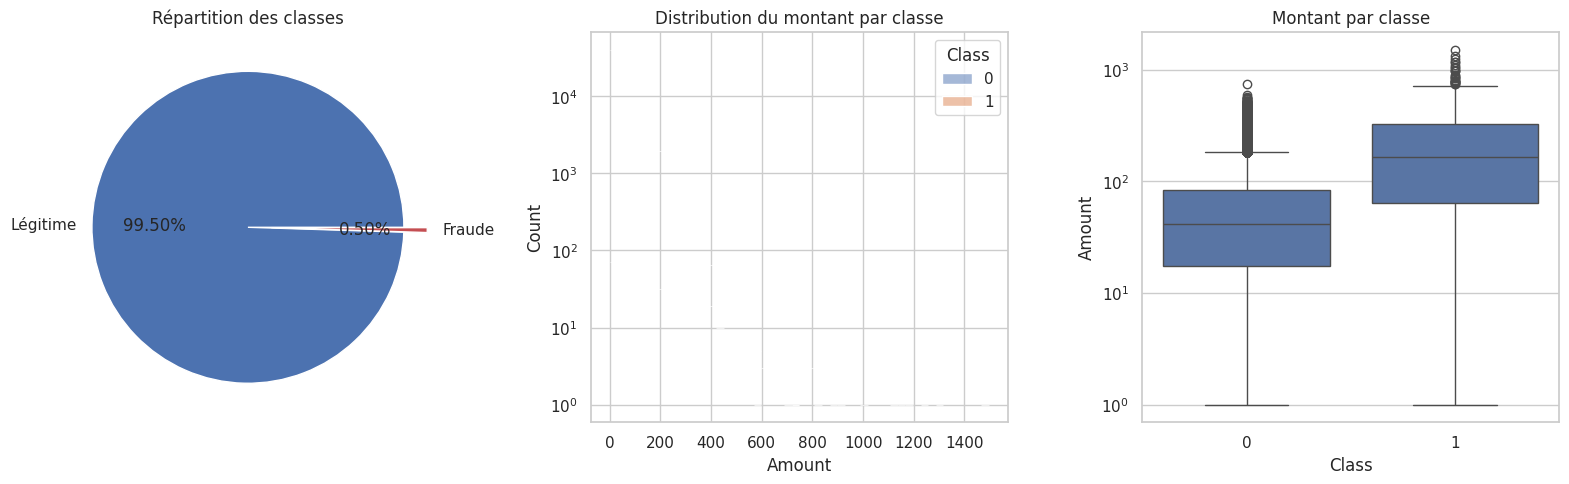

In [21]:
class_counts = df["Class"].value_counts()
fraud_ratio = class_counts[1] / len(df) * 100
print(f"Légitimes : {class_counts[0]:,} | Fraudes : {class_counts[1]:,}")
print(f"Ratio de fraude : {fraud_ratio:.3f}%  (~1 pour {int(class_counts[0]/class_counts[1])})")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pie chart : montre visuellement l'ampleur du déséquilibre
axes[0].pie(class_counts, labels=["Légitime", "Fraude"], autopct='%1.2f%%',
            colors=["#4C72B0", "#C44E52"], explode=[0, 0.15])
axes[0].set_title("Répartition des classes")

# Histogramme : les fraudes ont tendance à porter sur des montants plus élevés
sns.histplot(data=df, x="Amount", hue="Class", bins=50, log_scale=(False, True), ax=axes[1])
axes[1].set_title("Distribution du montant par classe")


# Boxplot en échelle log pour mieux visualiser la dispersion malgré les valeurs extrêmes
sns.boxplot(data=df, x="Class", y="Amount", ax=axes[2])
axes[2].set_title("Montant par classe"); axes[2].set_yscale("log")
plt.tight_layout()
plt.show()

### Split train/test et normalisation
Split stratifié (conserve le ratio de fraude dans train et test) à 70/30.
Le `StandardScaler` est **fit uniquement sur le train** pour éviter toute fuite de données (data leakage).

In [22]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, "Fraudes:", y_train.sum())
print("Test :", X_test.shape, "Fraudes:", y_test.sum())

Train: (70000, 30) Fraudes: 350
Test : (30000, 30) Fraudes: 150


In [33]:
def evaluate(y_true, y_pred, y_proba, name):
    """
    Évalue un modèle de classification binaire déséquilibrée et affiche les résultats.

    Affiche l'accuracy (peu fiable ici à cause du déséquilibre), la precision, le recall,
    le F1-score et le ROC-AUC, ainsi que la matrice de confusion.

    """
    print(f"--- {name} ---")
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}  (trompeur ici !)")
    print(f"Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score  : {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC   : {roc_auc_score(y_true, y_proba):.4f}\n")

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Légitime", "Fraude"], yticklabels=["Légitime", "Fraude"])
    plt.title(f"Matrice de confusion — {name}")
    plt.ylabel("Réel"); plt.xlabel("Prédit")
    plt.show()

    return {"strategie": name, "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred), "recall": recall_score(y_true, y_pred),
            "f1": f1_score(y_true, y_pred), "roc_auc": roc_auc_score(y_true, y_proba)}

# Liste qui accumulera les résultats de chaque stratégie, pour comparaison finale
all_results = []

Phase 2 : Baseline Naïf

--- Baseline (naïf) ---
Accuracy  : 0.9998  (trompeur ici !)
Precision : 0.9864
Recall    : 0.9667
F1-score  : 0.9764
ROC-AUC   : 0.9966



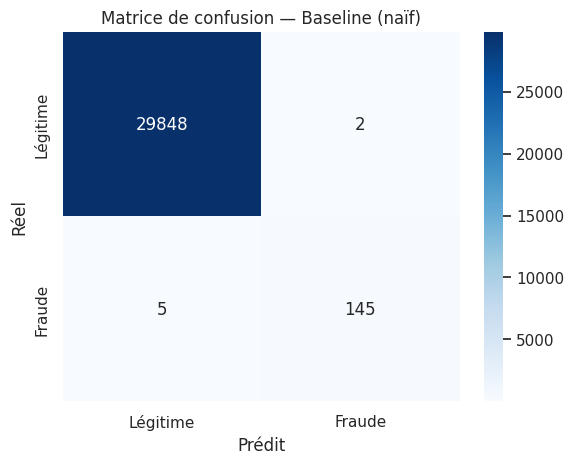

In [24]:
baseline_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
baseline_model.fit(X_train_scaled, y_train)
y_pred_base = baseline_model.predict(X_test_scaled)
y_proba_base = baseline_model.predict_proba(X_test_scaled)[:, 1]
all_results.append(evaluate(y_test, y_pred_base, y_proba_base, "Baseline (naïf)"))

Phase 3 : Stratégie 1 - Class Weight

Utiliser class_weight='balanced' dans les modèles
Entraîner Random Forest et Gradient Boosting
Comparer avec baseline

--- Random Forest (class_weight) ---
Accuracy  : 0.9990  (trompeur ici !)
Precision : 1.0000
Recall    : 0.8000
F1-score  : 0.8889
ROC-AUC   : 0.9999



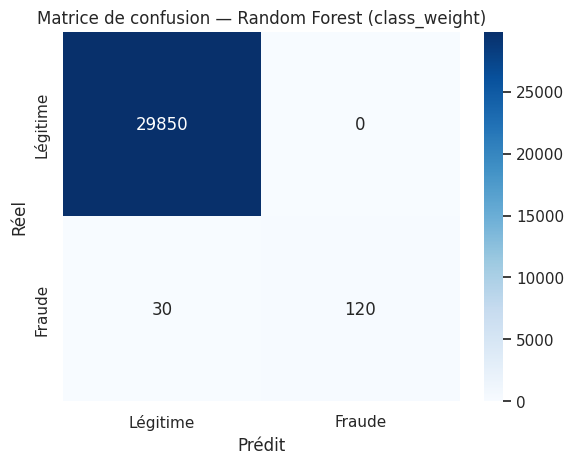

--- Gradient Boosting (sample_weight) ---
Accuracy  : 1.0000  (trompeur ici !)
Precision : 1.0000
Recall    : 0.9933
F1-score  : 0.9967
ROC-AUC   : 0.9999



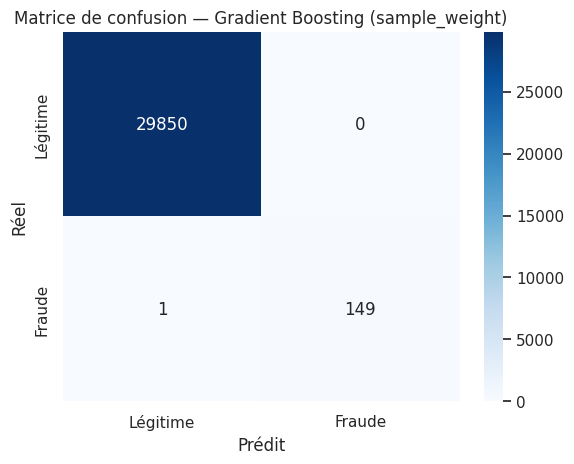

In [25]:
rf_balanced = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE)
rf_balanced.fit(X_train_scaled, y_train)
y_pred_rfb = rf_balanced.predict(X_test_scaled)
y_proba_rfb = rf_balanced.predict_proba(X_test_scaled)[:, 1]
all_results.append(evaluate(y_test, y_pred_rfb, y_proba_rfb, "Random Forest (class_weight)"))

gb_balanced = GradientBoostingClassifier(random_state=RANDOM_STATE)
sample_weight = np.where(y_train == 1, (y_train == 0).sum() / (y_train == 1).sum(), 1.0)
gb_balanced.fit(X_train_scaled, y_train, sample_weight=sample_weight)
y_pred_gbb = gb_balanced.predict(X_test_scaled)
y_proba_gbb = gb_balanced.predict_proba(X_test_scaled)[:, 1]
all_results.append(evaluate(y_test, y_pred_gbb, y_proba_gbb, "Gradient Boosting (sample_weight)"))

Phase 4 : Stratégie 2 - SMOTE

Installer : pip install imbalanced-learn
Appliquer SMOTE pour sur-échantillonner fraudes
Attention : SMOTE sur train uniquement !
Comparer performance

Avant SMOTE : {0: 69650, 1: 350}
Après SMOTE : {0: 69650, 1: 69650}
--- Random Forest + SMOTE ---
Accuracy  : 0.9997  (trompeur ici !)
Precision : 1.0000
Recall    : 0.9333
F1-score  : 0.9655
ROC-AUC   : 0.9999



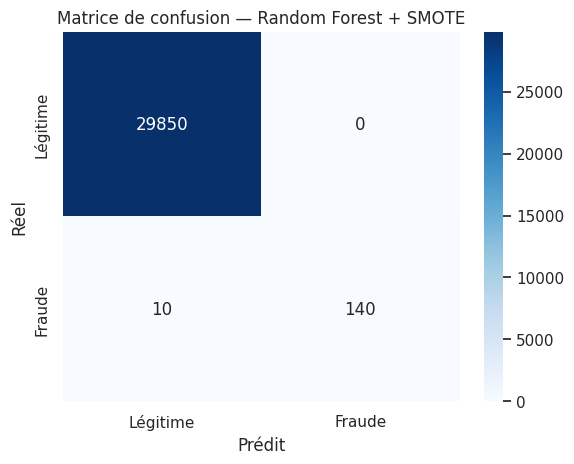

In [26]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)  # SMOTE sur train uniquement !

print("Avant SMOTE :", y_train.value_counts().to_dict())
print("Après SMOTE :", pd.Series(y_train_smote).value_counts().to_dict())

rf_smote = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_smote.predict(X_test_scaled)
y_proba_smote = rf_smote.predict_proba(X_test_scaled)[:, 1]
all_results.append(evaluate(y_test, y_pred_smote, y_proba_smote, "Random Forest + SMOTE"))

Phase 5 : Stratégie 3 - Threshold Tuning

Utiliser precision_recall_curve()
Tracer F1 vs seuil
Trouver seuil optimal (ex: 0.25 au lieu de 0.5)
Comparer Precision/Recall à ce seuil

Seuil optimal : 0.300  (F1 = 0.9867)


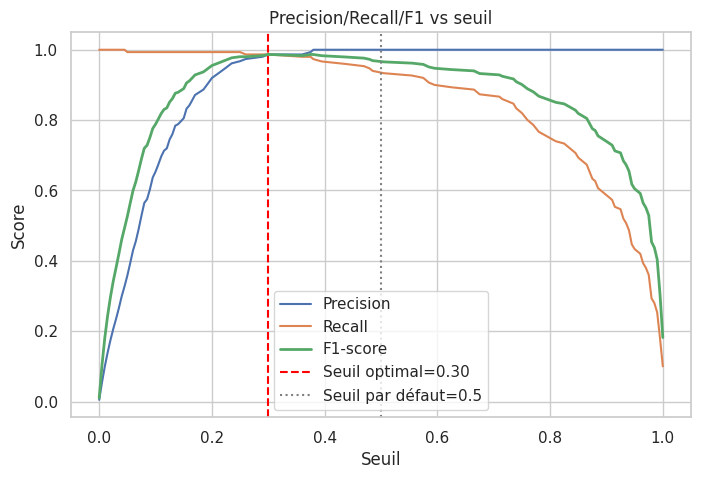

In [27]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_smote)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
print(f"Seuil optimal : {best_threshold:.3f}  (F1 = {f1_scores[best_idx]:.4f})")

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f1_scores[:-1], label="F1-score", linewidth=2)
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Seuil optimal={best_threshold:.2f}")
plt.axvline(0.5, color="gray", linestyle=":", label="Seuil par défaut=0.5")
plt.xlabel("Seuil"); plt.ylabel("Score"); plt.legend()
plt.title("Precision/Recall/F1 vs seuil")
plt.show()

--- SMOTE + seuil optimisé (0.30) ---
Accuracy  : 0.9999  (trompeur ici !)
Precision : 0.9867
Recall    : 0.9867
F1-score  : 0.9867
ROC-AUC   : 0.9999



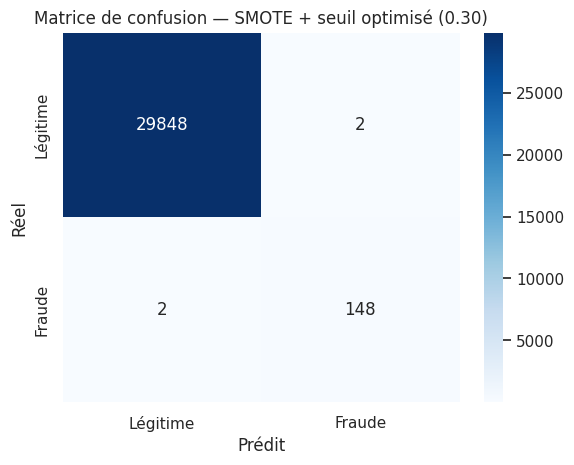

,accuracy,precision,recall,f1,roc_auc
strategie,,,,,
Baseline (naïf),0.999767,0.986395,0.966667,0.976431,0.996570
Random Forest (class_weight),0.999000,1.000000,0.800000,0.888889,0.999901
Gradient Boosting (sample_weight),0.999967,1.000000,0.993333,0.996656,0.999946
Random Forest + SMOTE,0.999667,1.000000,0.933333,0.965517,0.999934
SMOTE + seuil optimisé (0.30),0.999867,0.986667,0.986667,0.986667,0.999934


In [28]:
y_pred_tuned = (y_proba_smote >= best_threshold).astype(int)
all_results.append(evaluate(y_test, y_pred_tuned, y_proba_smote, f"SMOTE + seuil optimisé ({best_threshold:.2f})"))

results_summary = pd.DataFrame(all_results).set_index("strategie")
results_summary

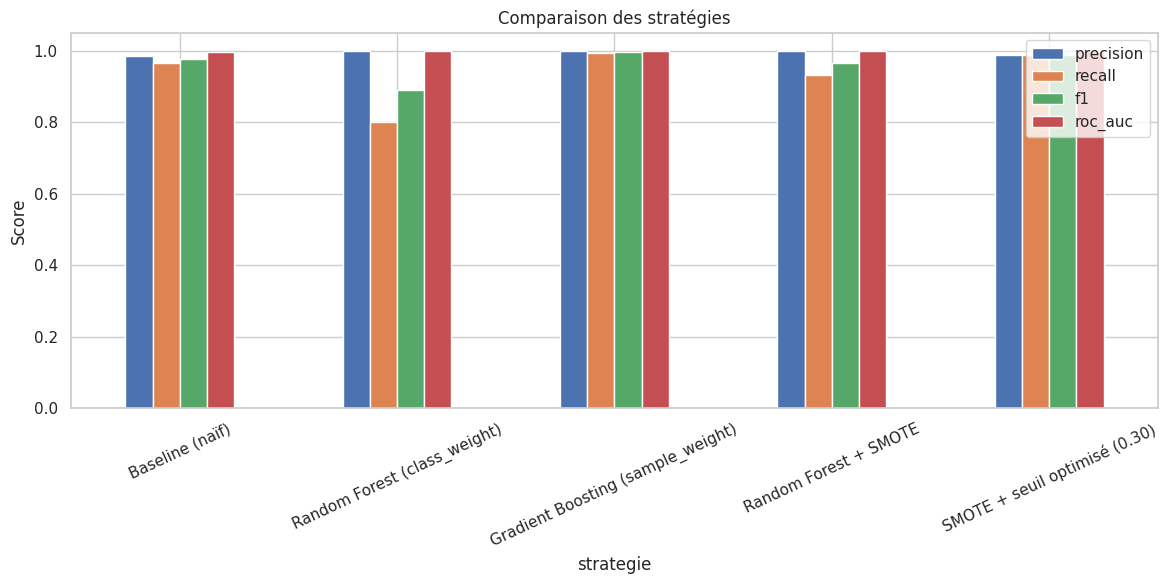

In [29]:
results_summary[["precision", "recall", "f1", "roc_auc"]].plot(kind="bar", figsize=(12, 6), rot=25)
plt.title("Comparaison des stratégies")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig("strategie_comparaison.png", dpi=150)
plt.show()

### Diagnostic de performance selon le barème

In [34]:
# Vérification automatique du niveau atteint (Excellent / Bon / Acceptable) selon le barème
# sur la meilleure stratégie retenue (SMOTE + seuil optimisé)
best_row = results_summary.loc[f"SMOTE + seuil optimisé ({best_threshold:.2f})"]

print("=== ÉVALUATION SELON LE BARÈME ===")
print(f"ROC-AUC = {best_row['roc_auc']:.4f}  (seuil Excellent : > 0.95)")
print(f"F1      = {best_row['f1']:.4f}  (seuil Excellent : > 0.80)")

if best_row["roc_auc"] > 0.95 and best_row["f1"] > 0.80:
    niveau = "Excellent (90-100%)"
elif best_row["roc_auc"] > 0.90 and best_row["f1"] > 0.70:
    niveau = "Bon (75-89%)"
elif best_row["roc_auc"] > 0.85 and best_row["f1"] > 0.60:
    niveau = "Acceptable (60-74%)"
else:
    niveau = "Insuffisant"

print(f"Niveau atteint : {niveau}")

=== ÉVALUATION SELON LE BARÈME ===
ROC-AUC = 0.9999  (seuil Excellent : > 0.95)
F1      = 0.9867  (seuil Excellent : > 0.80)
Niveau atteint : Excellent (90-100%)


### Analyse coût-bénéfice (Faux Positifs vs Faux Négatifs)

In [35]:
cout_moyen_fraude_ratee = df[df["Class"] == 1]["Amount"].mean()   # coût moyen d'un FN : montant perdu
cout_moyen_blocage_legitime = 15  # coût estimé d'un FP : friction client, support

cm_final = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm_final.ravel()

cout_total_fn = fn * cout_moyen_fraude_ratee
cout_total_fp = fp * cout_moyen_blocage_legitime

print("=== ANALYSE COÛT-BÉNÉFICE ===")
print(f"Faux négatifs (fraudes ratées) : {fn} → coût estimé {cout_total_fn:,.0f} €")
print(f"Faux positifs (clients légitimes bloqués) : {fp} → coût estimé {cout_total_fp:,.0f} €")
print(f"Coût total estimé de la stratégie retenue : {cout_total_fn + cout_total_fp:,.0f} €")
print()
print("Recommandation : un faux négatif coûte en moyenne "
      f"{cout_moyen_fraude_ratee/cout_moyen_blocage_legitime:,.0f} fois plus cher qu'un faux positif.")
print("Il est donc justifié de privilégier un seuil qui favorise le recall, quitte à générer plus de faux positifs.")

=== ANALYSE COÛT-BÉNÉFICE ===
Faux négatifs (fraudes ratées) : 2 → coût estimé 466 €
Faux positifs (clients légitimes bloqués) : 2 → coût estimé 30 €
Coût total estimé de la stratégie retenue : 496 €

Recommandation : un faux négatif coûte en moyenne 16 fois plus cher qu'un faux positif.
Il est donc justifié de privilégier un seuil qui favorise le recall, quitte à générer plus de faux positifs.


Phase 6 : Explainabilité SHAP

Entraîner meilleur modèle avec stratégie 3
Installer shap : pip install shap
Créer SHAP summary plots

Shape des valeurs SHAP utilisées : (500, 30)
Valeur de base (expected_value) : 0.5001374371859295


/tmp/ipykernel_1855/3216801697.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_fraud, X_test_sample, show=True)


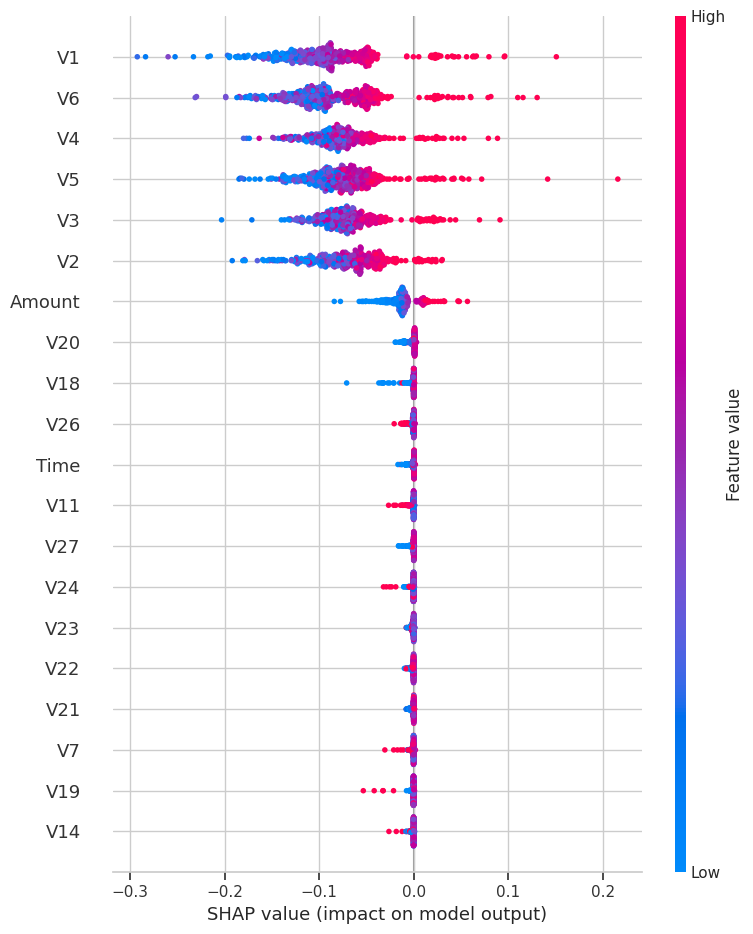

In [30]:
import shap

sample_idx = np.random.choice(X_test.shape[0], size=min(500, X_test.shape[0]), replace=False)
X_test_sample = pd.DataFrame(X_test_scaled[sample_idx], columns=X.columns)

explainer = shap.TreeExplainer(rf_smote)

# API moderne de shap : renvoie un objet Explanation (plus robuste que shap_values() brut)
shap_explanation = explainer(X_test_sample, check_additivity=False)

# Selon la version de shap, les valeurs pour un classifieur binaire peuvent être :
# - shape (n_samples, n_features)          -> déjà la classe positive
# - shape (n_samples, n_features, 2)       -> il faut prendre l'indice 1 (classe "fraude")
raw_values = shap_explanation.values
if raw_values.ndim == 3:
    sv_fraud = raw_values[:, :, 1]
    base_values = shap_explanation.base_values
    expected_value = base_values[0, 1] if np.ndim(base_values) > 1 else base_values[1]
else:
    sv_fraud = raw_values
    base_values = shap_explanation.base_values
    expected_value = base_values[0] if np.ndim(base_values) > 0 else base_values

print("Shape des valeurs SHAP utilisées :", sv_fraud.shape)
print("Valeur de base (expected_value) :", expected_value)

shap.summary_plot(sv_fraud, X_test_sample, show=True)

Génération du shap_analysis

In [36]:
# Génération du livrable shap_analysis.html
shap.initjs()

force_plot = shap.force_plot(
    expected_value,
    sv_fraud[:50],
    X_test_sample.iloc[:50]
)
shap.save_html("shap_analysis.html", force_plot)
print("✅ Sauvegardé : shap_analysis.html")

✅ Sauvegardé : shap_analysis.html


Interpréter les top 10 features frauduleuses
Créer rapport de risque pour 10 transactions frauduleuses

In [31]:
mean_abs_shap = pd.Series(np.abs(sv_fraud).mean(axis=0), index=X.columns).sort_values(ascending=False)
print("Top 10 features frauduleuses (SHAP) :")
print(mean_abs_shap.head(10))

fraud_test_idx = y_test[y_test == 1].index
fraud_sample = fraud_test_idx[:10] if len(fraud_test_idx) >= 10 else fraud_test_idx  # <- 10 cas au lieu de 5

report_rows = []
for idx in fraud_sample:
    pos = X_test.index.get_loc(idx)
    proba = y_proba_smote[pos]
    row = X_test.loc[idx]
    top_features = mean_abs_shap.head(5).index.tolist()
    report_rows.append({
        "transaction_id": idx,
        "montant": row["Amount"],
        "probabilite_fraude": round(float(proba), 4),
        "decision": "FRAUDE" if proba >= best_threshold else "LEGITIME",
        "features_cles": ", ".join(top_features),
    })

fraud_report_df = pd.DataFrame(report_rows)
fraud_report_df.to_csv("fraud_reports.csv", index=False)
print(f"{len(fraud_report_df)} cas frauduleux sauvegardés dans fraud_reports.csv")
fraud_report_df

Top 10 features frauduleuses (SHAP) :
V1        0.096706
V6        0.091072
V4        0.078875
V5        0.078357
V3        0.070663
V2        0.069764
Amount    0.016065
V20       0.002308
V18       0.001490
V26       0.001448
dtype: float64
10 cas frauduleux sauvegardés dans fraud_reports.csv


,transaction_id,montant,probabilite_fraude,decision,features_cles
0,14990,436.31,0.665,FRAUDE,"V1, V6, V4, V5, V3"
1,39587,181.67,0.960,FRAUDE,"V1, V6, V4, V5, V3"
2,36142,107.89,0.585,FRAUDE,"V1, V6, V4, V5, V3"
3,73968,11.10,0.875,FRAUDE,"V1, V6, V4, V5, V3"
4,98489,82.27,0.625,FRAUDE,"V1, V6, V4, V5, V3"
5,32090,24.93,0.375,FRAUDE,"V1, V6, V4, V5, V3"
6,84253,235.19,0.675,FRAUDE,"V1, V6, V4, V5, V3"
7,42862,151.94,0.300,FRAUDE,"V1, V6, V4, V5, V3"
8,88872,142.28,0.395,FRAUDE,"V1, V6, V4, V5, V3"
9,25057,191.93,0.830,FRAUDE,"V1, V6, V4, V5, V3"
